In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc as odbc

In [2]:
conexion = odbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=.\\SQLEXPRESS;"
    "DATABASE=DBVentas;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

In [3]:
query="""
    SELECT r.ID as ID, r.Order_ID AS Order_ID, r.Order_Date AS Order_Date, r.Ship_Date as Ship_Date, r.Ship_Mode as Ship_Mode, r.Customer_ID as Customer_ID,
       c.Name_C as Customer_Name, c.Segment as Segment, c.Country as Country, c.City as City, c.State as State, c.Region as Region,
       r.Product_ID as Product_ID, p.Name_P as Product_Name, p.Category as Category, p.Sub_cateogry as Sub_Category,
       r.Sales as Sales, r.Quantity as Quantity, r.Profit as Profit, r.Returns as Returns, r.Payment_Mode as Payment_Mode
        FROM RegistroVentas r INNER JOIN Customers c on r.Customer_ID=c.ID_C INNER JOIN Products p ON r.Product_ID=p.ID_P
"""
df=pd.read_sql_query(query, conexion)

C:\Users\mateo\AppData\Local\Temp\ipykernel_22964\3526789169.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query, conexion)


In [4]:
df.head()

,ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Region,Product_ID,Product_Name,Category,Sub_Category,Sales,Quantity,Profit,Returns,Payment_Mode
0,1160,CA-2020-147039,2020-06-29,2020-07-04,Standard Class,AA-10315,Alex Avila,Consumer,United States,Round Rock,...,Central,OFF-AP-10000576,Belkin 7 Outlet SurgeMaster II,Office Supplies,Appliances,40194.0,3,907.35,#N/A,Online
1,1161,CA-2020-147039,2020-06-29,2020-07-04,Standard Class,AA-10315,Alex Avila,Consumer,United States,Round Rock,...,Central,OFF-BI-10004654,Avery Binding System Hidden Tab Executive Styl...,Office Supplies,Binders,11154.0,2,5.77,#N/A,COD
2,5200,CA-2019-103982,2019-03-03,2019-03-08,Standard Class,AA-10315,Alex Avila,Consumer,United States,Round Rock,...,Central,OFF-FA-10001332,"Acco Banker's Clasps, 5 3/4""-Long",Office Supplies,Fasteners,2304.0,1,77.76,#N/A,Online
3,5199,CA-2019-103982,2019-03-03,2019-03-08,Standard Class,AA-10315,Alex Avila,Consumer,United States,Round Rock,...,Central,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,3930072.0,3,-78601.44,#N/A,Online
4,5202,CA-2019-103982,2019-03-03,2019-03-08,Standard Class,AA-10315,Alex Avila,Consumer,United States,Round Rock,...,Central,TEC-AC-10002857,Verbatim 25 GB 6x Blu-ray Single Layer Recorda...,Technology,Accessories,4172.0,7,573.65,#N/A,Cards


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             5901 non-null   int64  
 1   Order_ID       5901 non-null   str    
 2   Order_Date     5901 non-null   object 
 3   Ship_Date      5901 non-null   object 
 4   Ship_Mode      5901 non-null   str    
 5   Customer_ID    5901 non-null   str    
 6   Customer_Name  5901 non-null   str    
 7   Segment        5901 non-null   str    
 8   Country        5901 non-null   str    
 9   City           5901 non-null   str    
 10  State          5901 non-null   str    
 11  Region         5901 non-null   str    
 12  Product_ID     5901 non-null   str    
 13  Product_Name   5901 non-null   str    
 14  Category       5901 non-null   str    
 15  Sub_Category   5901 non-null   str    
 16  Sales          5901 non-null   float64
 17  Quantity       5901 non-null   int64  
 18  Profit         5901

In [6]:
df.describe()

,ID,Sales,Quantity,Profit
count,5901.000000,5.901000e+03,5901.000000,5901.000000
mean,5022.422471,1.317547e+05,3.781901,1921.646648
std,2877.977184,5.189775e+05,2.212917,18135.032097
min,1.000000,3.000000e+00,1.000000,-383999.040000
25%,2486.000000,8.448000e+03,2.000000,23.080000
50%,5091.000000,1.929600e+04,3.000000,357.420000
75%,7456.000000,1.144240e+05,5.000000,1469.020000
max,9994.000000,2.396266e+07,14.000000,671998.080000


In [7]:
df.drop_duplicates()
df.shape

(5901, 21)

In [8]:
## Categorias que generan mayor rentabilidad
df_categorias=df.groupby('Category')['Profit'].agg(['sum']).reset_index()
df_categorias.columns=['Categorias','Ganancias']
df_categorias

,Categorias,Ganancias
0,Furniture,372597.83
1,Office Supplies,4780415.81
2,Technology,6186623.23


In [9]:
## Productos que presentan perdidas
df_productos_ganancias=df.groupby('Product_Name')['Profit'].agg(['sum']).reset_index()
df_productos_ganancias.columns=['Producto','Ganancias']
df_productos_perdidas=df_productos_ganancias[df_productos_ganancias['Ganancias']<0]

## Top 5 productos que presentan perdidas
df_productos_perdidas.sort_values(ascending=1, by='Ganancias').head()

,Producto,Ganancias
449,Cubify CubeX 3D Printer Triple Head Print,-383999.04
357,Bush Advantage Collection Racetrack Conference...,-201923.96
973,Martin Yale Chadless Opener Electric Letter Op...,-130751.17
834,Ibico EPK-21 Electric Binding System,-128519.32
566,Epson TM-T88V Direct Thermal Printer - Monochr...,-93595.95


In [10]:
## Que regiones tienen mejor desempenio
df_regiones=(df.groupby('Region').agg(
          Total_Sales=('Sales', 'sum'),
          Total_Profit=('Profit', 'sum'),
          Orders=('Order_ID', 'count')
      )
).reset_index()

df_regiones.sort_values(ascending=0,by='Total_Profit')

,Region,Total_Sales,Total_Profit,Orders
3,West,270425858.0,4104841.20,1921
1,East,198875241.0,4097389.59,1775
0,Central,182322448.0,1681359.45,1217
2,South,125860815.0,1456046.63,988


In [11]:
## productos con mas perdidas
df_productos=(df.groupby('Product_Name').agg(
        Sales=('Sales','sum'),
        Profit=('Profit','sum'),
        Orders=('Order_ID','count')
    )
).reset_index()

df_productos.sort_values(ascending=1,by=('Profit')).head()

,Product_Name,Sales,Profit,Orders
449,Cubify CubeX 3D Printer Triple Head Print,300998.0,-383999.04,1
357,Bush Advantage Collection Racetrack Conference...,3188733.0,-201923.96,4
973,Martin Yale Chadless Opener Electric Letter Op...,6662199.0,-130751.17,4
834,Ibico EPK-21 Electric Binding System,4726175.0,-128519.32,2
566,Epson TM-T88V Direct Thermal Printer - Monochr...,692995.0,-93595.95,1


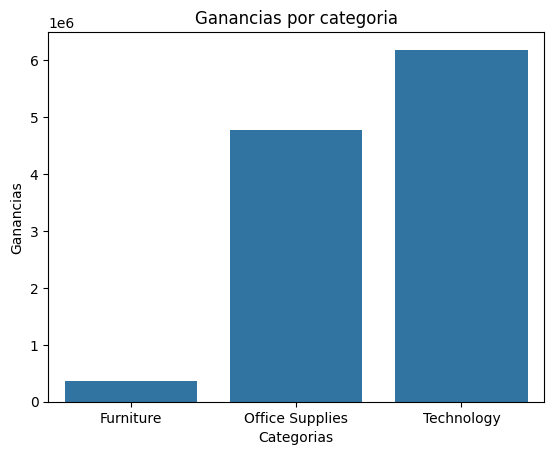

In [13]:

sns.barplot(data=df_categorias, x='Categorias',y='Ganancias')
plt.title('Ganancias por categoria')
plt.show()

In [15]:
df_top5_productos_perdidas=df_productos.sort_values(ascending=1,by=('Profit')).head()

df_top5_productos_perdidas

,Product_Name,Sales,Profit,Orders
449,Cubify CubeX 3D Printer Triple Head Print,300998.0,-383999.04,1
357,Bush Advantage Collection Racetrack Conference...,3188733.0,-201923.96,4
973,Martin Yale Chadless Opener Electric Letter Op...,6662199.0,-130751.17,4
834,Ibico EPK-21 Electric Binding System,4726175.0,-128519.32,2
566,Epson TM-T88V Direct Thermal Printer - Monochr...,692995.0,-93595.95,1


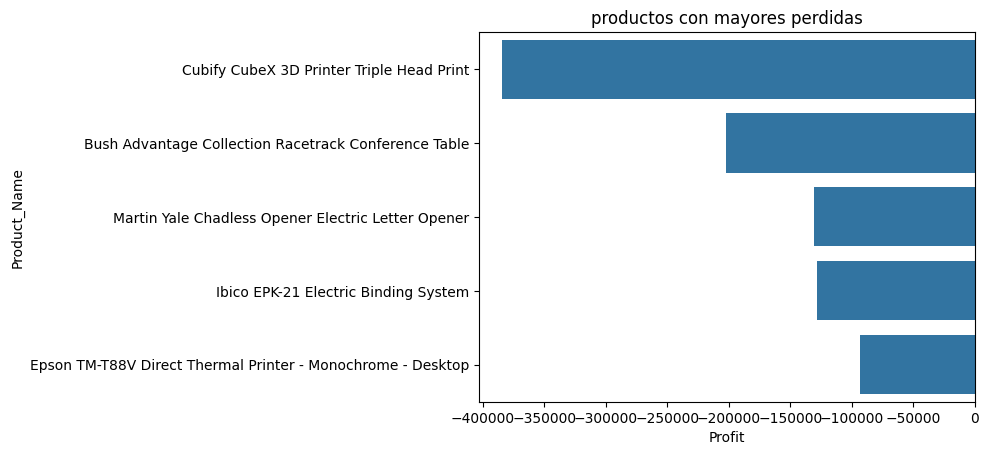

In [17]:
sns.barplot(data=df_top5_productos_perdidas,x='Profit',y='Product_Name')
plt.title('productos con mayores perdidas')
plt.show()

In [ ]:
##conexion.close()